# EEG S-JEPA Downstream Results Comparison

Aggregate and compare downstream fine-tuning results across paradigms and pretraining checkpoints.

- Paradigms: SSVEP, MI, ERP
- Fine-tuning schemes: configurable
- Pretraining checkpoints: 16s-60% (primary) + placeholders for extension
- Metrics: accuracy with error bars from cross-validation folds

# 1. Setup

## 1.1. Import Libraries

In [1]:
import sys
from pathlib import Path
import platform
import json
import hashlib
from datetime import datetime
from typing import Dict, List, Tuple, Optional, Any

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import builtins

print("All imports loaded successfully.")

All imports loaded successfully.


## 1.2. Runtime & Path Validation

In [2]:
print("Runtime Environment:")
print(f"  - Python: {sys.version}")
print(f"  - Platform: {platform.platform()}")

WORKING_DIR = Path.cwd().parent.parent
print(f"\nWorking directory: {WORKING_DIR}")

# Verify project structure
artifacts_dir = WORKING_DIR / "artifacts"
if not artifacts_dir.exists():
    raise FileNotFoundError(f"Artifacts directory not found at {artifacts_dir}")
else:
    print(f"Artifacts directory exists: {artifacts_dir}")

Runtime Environment:
  - Python: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.0.13.3)]
  - Platform: macOS-26.2-arm64-arm-64bit

Working directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA
Artifacts directory exists: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts


# 2. Configuration

## 2.1. Config

In [3]:
CONFIG = {
    # Output artifact directory for this notebook
    "artifact_dir": str(WORKING_DIR / "downstream_comparisons"),
    
    # Metrics to extract and plot
    "metric_key": "mean_accuracy",
    "std_key": "std_accuracy",
    
    # Display ordering (configure later as you add more pretraining checkpoints)
    "paradigm_order": ["ERP", "SSVEP", "MI"],
    "scheme_order": ["full", "new"],  # Fine-tuning schemes
    "pretraining_order": ["1s-40%", "1s-60%", "1s-80%", "4s-40%", "4s-60%", "4s-80%", "16s-40%", "16s-60%", "16s-80%"],
    
    # Chance level and reference lines by paradigm
    "chance_levels": {
        "ERP": 0.5,      # 2-class
        "MI": 0.5,       # 2-class
        "SSVEP": 0.25,   # 4-class
    },
    
    # Optional reference/best lines (set to None to disable)
    "best_known": {
        "ERP": None,
        "MI": None,
        "SSVEP": None,
    },
    
    # Plotting options
    "annotate_missing": True,
    "save_figures": True,
    "save_tables": False,
}

## 2.2. Result Paths Mapping

In [4]:
# IMPORTANT: Update these paths to point to your actual artifact folders.
# Each path should point to a run folder containing global_metrics.json
# Set to None for combinations you do not yet have results for.

RESULT_PATHS = {
    "ERP": {
        "full-contextual": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": None,
            "16s-80%": None,
        },
        "full-prelocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": None,
            "16s-80%": None,
        },
        "full-postlocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": None,
            "16s-80%": None,
        },
        "new-contextual": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/ERP/20260415_2106_45070b97",
            "16s-80%": None,
        },
        "new-prelocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/ERP/20260415_2024_06e2f4d8",
            "16s-80%": None,
        },
        "new-postlocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/ERP/20260415_2057_f7ade870",
            "16s-80%": None,
        },
    },
    "SSVEP": {
        "full-contextual": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": None,
            "16s-80%": None,
        },
        "full-prelocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_2309_6fffcc9d",
            "16s-80%": None,
        },
        "full-postlocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260415_0002_33e6e683",
            "16s-80%": None,
        },
        "new-contextual": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_1628_17dccc1e",
            "16s-80%": None,
        },
        "new-prelocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_1613_f1d1bf68",
            "16s-80%": None,
        },
        "new-postlocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/SSVEP/20260414_1626_4fc84d8a",
            "16s-80%": None,
        },
    },
    "MI": {
        "full-contextual": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": None,
            "16s-80%": None,
        },
        "full-prelocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1748_bd821a35",
            "16s-80%": None,
        },
        "full-postlocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1842_e3b5a534",
            "16s-80%": None,
        },
        "new-contextual": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1253_e64b3856",
            "16s-80%": None,
        },
        "new-prelocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1243_fe097e91",
            "16s-80%": None,
        },
        "new-postlocal": {
            "1s-40%": None,
            "1s-60%": None,
            "1s-80%": None,
            "4s-40%": None,
            "4s-60%": None,
            "4s-80%": None,
            "16s-40%": None,
            "16s-60%": "artifacts/lee-2019-fine-tuning/MI/20260415_1250_4f3e6fdd",
            "16s-80%": None,
        },
    },
}

## 2.3. Create Artifact Directory

In [5]:
def create_run_id():
    """Generate unique run ID from timestamp + config hash."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")
    config_str = json.dumps(CONFIG, sort_keys=True, default=str)
    config_hash = hashlib.md5(config_str.encode()).hexdigest()[:8]
    return f"{timestamp}_project_comparison_{config_hash}"

RUN_ID = create_run_id()
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID: {RUN_ID}")
print(f"Artifact directory: {ARTIFACT_DIR}")

Run ID: 20260416_1056_project_comparison_b11605e6
Artifact directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1056_project_comparison_b11605e6


## 2.4. Initialize Logger

In [6]:
LOG_PATH = ARTIFACT_DIR / "run.log"
_LOG_FILE_HANDLE = open(LOG_PATH, "a", buffering=1)

def _timestamped_print(*args, **kwargs):
    """Print with timestamps to both console and log file."""
    sep = kwargs.pop("sep", " ")
    end = kwargs.pop("end", "\n")
    flush = kwargs.pop("flush", False)
    file = kwargs.pop("file", None)

    message = sep.join(str(arg) for arg in args)

    # Preserve visual spacing for prints like print("\n...")
    leading_newlines = len(message) - len(message.lstrip("\n"))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text) # type: ignore
            if flush:
                sys.__stdout__.flush() # type: ignore
        else:
            file.write(text)
            if flush and hasattr(file, "flush"):
                file.flush()

    # Apply leading blank lines first without timestamps
    if leading_newlines > 0:
        blanks = "\n" * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        stamped = f"[{ts}] {message_body}"
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        # If only newlines were printed, preserve end behavior without adding a timestamp
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print
print("Logger initialized.")

[2026-04-16 10:56:16] Logger initialized.


## 2.5. Save Configuration

In [7]:
print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
for key in sorted(CONFIG.keys()):
    print(f"  {key}: {CONFIG[key]}")
print("=" * 70)

config_path = ARTIFACT_DIR / "config.json"
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2, default=str)
print(f"Config saved to: {config_path}")

[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16] CONFIGURATION
[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16]   annotate_missing: True
[2026-04-16 10:56:16]   artifact_dir: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons
[2026-04-16 10:56:16]   best_known: {'ERP': None, 'MI': None, 'SSVEP': None}
[2026-04-16 10:56:16]   chance_levels: {'ERP': 0.5, 'MI': 0.5, 'SSVEP': 0.25}
[2026-04-16 10:56:16]   metric_key: mean_accuracy
[2026-04-16 10:56:16]   paradigm_order: ['ERP', 'SSVEP', 'MI']
[2026-04-16 10:56:16]   pretraining_order: ['1s-40%', '1s-60%', '1s-80%', '4s-40%', '4s-60%', '4s-80%', '16s-40%', '16s-60%', '16s-80%']
[2026-04-16 10:56:16]   save_figures: True
[2026-04-16 10:56:16]   save_tables: False
[2026-04-16 10:56:16]   scheme_order: ['full', 'new']
[2026-04-16 10:56:16]   std_key: std_accurac

# 3. Result Loading Utilities

## 3.1. Safe JSON Reader

In [8]:
def safe_read_json(file_path: Path) -> Tuple[Optional[Dict], str]:
    """
    Safely read JSON file and return data + status.
    
    Returns:
        (data_dict, status_str) where status is 'ok', 'missing_file', or 'json_error'
    """
    if not file_path.exists():
        return None, "missing_file"
    
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
        return data, "ok"
    except json.JSONDecodeError as e:
        return None, f"json_error: {str(e)}"
    except Exception as e:
        return None, f"read_error: {str(e)}"

print("safe_read_json defined.")

[2026-04-16 10:56:16] safe_read_json defined.


## 3.2. Metrics Loader

In [9]:
def load_metrics(
    paradigm: str,
    scheme: str,
    pretraining: str,
    run_path: Optional[str],
    metric_key: str,
    std_key: str,
) -> Dict[str, Any]:
    """
    Load metrics from global_metrics.json for a single configuration.
    
    Returns a dict with:
        - paradigm, scheme, pretraining (always present)
        - status: 'ok', 'missing_path', 'missing_metrics_file', 'json_error', 'missing_metric_key'
        - metric_value, std_value: populated if status == 'ok'
        - error_msg: human-readable error message
    """
    result = {
        "paradigm": paradigm,
        "scheme": scheme,
        "pretraining": pretraining,
        "status": None,
        "metric_value": None,
        "std_value": None,
        "error_msg": None,
    }
    
    # Check if path is configured
    if run_path is None:
        result["status"] = "missing_path"
        result["error_msg"] = "No path configured"
        return result
    
    # Resolve path
    run_path_obj = Path(run_path)
    if not run_path_obj.is_absolute():
        run_path_obj = WORKING_DIR / run_path_obj
    
    # Check if metrics file exists
    metrics_file = run_path_obj / "global_metrics.json"
    if not metrics_file.exists():
        result["status"] = "missing_metrics_file"
        result["error_msg"] = f"File not found: {metrics_file}"
        return result
    
    # Load JSON
    data, json_status = safe_read_json(metrics_file)
    if json_status != "ok":
        result["status"] = json_status if "error" in json_status else "json_error"
        result["error_msg"] = json_status
        return result
    
    # Extract metrics
    if metric_key not in data: # type: ignore
        result["status"] = "missing_metric_key"
        result["error_msg"] = f"Metric key '{metric_key}' not found in {metrics_file}"
        return result
    
    result["status"] = "ok"
    result["metric_value"] = float(data[metric_key]) # type: ignore
    result["std_value"] = float(data.get(std_key, 0.0)) # type: ignore
    
    return result

print("load_metrics defined.")

[2026-04-16 10:56:16] load_metrics defined.


## 3.3. Build Results Table

In [10]:
def build_results_dataframe(
    result_paths: Dict,
    CONFIG: Dict,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Build results dataframe by iterating all configured combinations.
    
    Returns:
        (all_results_df, successful_df, missing_df)
    """
    all_rows = []
    
    for paradigm in CONFIG["paradigm_order"]:
        if paradigm not in result_paths:
            continue
        
        for scheme in CONFIG["scheme_order"]:
            # Construct full scheme key if needed
            # Schemes may be stored as "full-contextual", "new-contextual", etc.
            # For now, try the direct scheme name first
            scheme_variants = [scheme]
            if scheme == "full":
                scheme_variants = [k for k in result_paths[paradigm].keys() if k.startswith("full")]
            elif scheme == "new":
                scheme_variants = [k for k in result_paths[paradigm].keys() if k.startswith("new")]
            
            for scheme_key in scheme_variants:
                if scheme_key not in result_paths[paradigm]:
                    continue
                
                for pretraining in CONFIG["pretraining_order"]:
                    run_path = result_paths[paradigm][scheme_key].get(pretraining)
                    
                    row = load_metrics(
                        paradigm=paradigm,
                        scheme=scheme_key,
                        pretraining=pretraining,
                        run_path=run_path,
                        metric_key=CONFIG["metric_key"],
                        std_key=CONFIG["std_key"],
                    )
                    all_rows.append(row)
    
    all_df = pd.DataFrame(all_rows)
    successful_df = all_df[all_df["status"] == "ok"].copy()
    missing_df = all_df[all_df["status"] != "ok"].copy()
    
    return all_df, successful_df, missing_df

print("build_results_dataframe defined.")

[2026-04-16 10:56:16] build_results_dataframe defined.


# 4. Load and Inspect Results

## 4.1. Build Results DataFrame

In [11]:
print("\nLoading results from configured paths...\n")

all_results, successful_results, missing_results = build_results_dataframe(RESULT_PATHS, CONFIG)

print(f"Total configured combinations: {len(all_results)}")
print(f"Successfully loaded: {len(successful_results)}")
print(f"Missing/invalid: {len(missing_results)}")


[2026-04-16 10:56:16] Loading results from configured paths...

[2026-04-16 10:56:16] Total configured combinations: 162
[2026-04-16 10:56:16] Successfully loaded: 13
[2026-04-16 10:56:16] Missing/invalid: 149


## 4.2. Loaded Results Overview

In [12]:
print("\n" + "=" * 70)
print("SUCCESSFULLY LOADED RESULTS")
print("=" * 70)

if len(successful_results) > 0:
    display_cols = ["paradigm", "scheme", "pretraining", "metric_value", "std_value", "status"]
    print(successful_results[display_cols].to_string(index=False))
else:
    print("No successful results loaded yet. Update RESULT_PATHS with actual artifact paths.")

print()


[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16] SUCCESSFULLY LOADED RESULTS
[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16] paradigm         scheme pretraining  metric_value    std_value status
     ERP new-contextual     16s-60%      0.833333 1.110223e-16     ok
     ERP   new-prelocal     16s-60%      0.893831 2.402570e-02     ok
     ERP  new-postlocal     16s-60%      0.878608 2.022713e-02     ok
   SSVEP  full-prelocal     16s-60%      0.898571 1.514151e-01     ok
   SSVEP full-postlocal     16s-60%      0.696429 2.176287e-01     ok
   SSVEP new-contextual     16s-60%      0.250000 0.000000e+00     ok
   SSVEP   new-prelocal     16s-60%      0.917857 1.205007e-01     ok
   SSVEP  new-postlocal     16s-60%      0.536429 1.969720e-01     ok
      MI  full-prelocal     16s-60%      0.569286 9.730029e-02     ok
      MI full-postlocal     16s-60%      

## 4.3. Missing Results Overview

In [13]:
print("\n" + "=" * 70)
print("MISSING OR INVALID RESULTS")
print("=" * 70)

if len(missing_results) > 0:
    display_cols = ["paradigm", "scheme", "pretraining", "status", "error_msg"]
    print(missing_results[display_cols].to_string(index=False))
else:
    print("No missing results (all configured paths are valid).")

print()


[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16] MISSING OR INVALID RESULTS
[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16] paradigm          scheme pretraining       status          error_msg
     ERP full-contextual      1s-40% missing_path No path configured
     ERP full-contextual      1s-60% missing_path No path configured
     ERP full-contextual      1s-80% missing_path No path configured
     ERP full-contextual      4s-40% missing_path No path configured
     ERP full-contextual      4s-60% missing_path No path configured
     ERP full-contextual      4s-80% missing_path No path configured
     ERP full-contextual     16s-40% missing_path No path configured
     ERP full-contextual     16s-60% missing_path No path configured
     ERP full-contextual     16s-80% missing_path No path configured
     ERP   full-prelocal      1s-40% missing_path No

## 4.4. Coverage Summary

In [14]:
print("\n" + "=" * 70)
print("COVERAGE SUMMARY")
print("=" * 70)

# Summary by paradigm
print("\nBy Paradigm:")
for paradigm in CONFIG["paradigm_order"]:
    paradigm_all = all_results[all_results["paradigm"] == paradigm]
    paradigm_ok = successful_results[successful_results["paradigm"] == paradigm]
    print(f"  {paradigm:8s}: {len(paradigm_ok):3d} / {len(paradigm_all):3d} loaded")

# Summary by scheme
print("\nBy Fine-tuning Scheme:")
all_schemes = successful_results["scheme"].unique()
for scheme in sorted(all_schemes):
    scheme_ok = successful_results[successful_results["scheme"] == scheme]
    scheme_all = all_results[all_results["scheme"] == scheme]
    print(f"  {scheme:20s}: {len(scheme_ok):3d} / {len(scheme_all):3d} loaded")

# Summary by pretraining
print("\nBy Pretraining Checkpoint:")
for pretraining in CONFIG["pretraining_order"]:
    pt_ok = successful_results[successful_results["pretraining"] == pretraining]
    pt_all = all_results[all_results["pretraining"] == pretraining]
    if len(pt_all) > 0:
        print(f"  {pretraining:10s}: {len(pt_ok):3d} / {len(pt_all):3d} loaded")

print()


[2026-04-16 10:56:16] ======================================================================
[2026-04-16 10:56:16] COVERAGE SUMMARY
[2026-04-16 10:56:16] ======================================================================

[2026-04-16 10:56:16] By Paradigm:
[2026-04-16 10:56:16]   ERP     :   3 /  54 loaded
[2026-04-16 10:56:16]   SSVEP   :   5 /  54 loaded
[2026-04-16 10:56:16]   MI      :   5 /  54 loaded

[2026-04-16 10:56:16] By Fine-tuning Scheme:
[2026-04-16 10:56:16]   full-postlocal      :   2 /  27 loaded
[2026-04-16 10:56:16]   full-prelocal       :   2 /  27 loaded
[2026-04-16 10:56:16]   new-contextual      :   3 /  27 loaded
[2026-04-16 10:56:16]   new-postlocal       :   3 /  27 loaded
[2026-04-16 10:56:16]   new-prelocal        :   3 /  27 loaded

[2026-04-16 10:56:16] By Pretraining Checkpoint:
[2026-04-16 10:56:16]   1s-40%    :   0 /  18 loaded
[2026-04-16 10:56:16]   1s-60%    :   0 /  18 loaded
[2026-04-16 10:56:16]   1s-80%    :   0 /  18 loaded
[2026-04-16 10:

# 5. Plotting

## 5.1. Plot Helpers

In [15]:
def get_pretraining_colors(pretraining_order: List[str]) -> Dict[str, str]:
    """
    Assign distinct colors to pretraining checkpoints.
    """
    # Use a qualitative colormap
    cmap = plt.cm.get_cmap('tab10')
    colors = {}
    for i, pt in enumerate(pretraining_order):
        colors[pt] = cmap(i % 10)
    return colors

def plot_paradigm_comparison(
    paradigm: str,
    successful_results: pd.DataFrame,
    CONFIG: Dict,
    colors: Dict[str, str],
    ax: plt.Axes, # type: ignore
) -> None:
    """
    Plot comparison of fine-tuning schemes + pretraining for one paradigm.
    
    X-axis: schemes
    Bars: pretraining labels
    Error bars: std_accuracy
    """
    paradigm_data = successful_results[successful_results["paradigm"] == paradigm]
    
    if len(paradigm_data) == 0:
        # No data for this paradigm; show placeholder
        ax.text(0.5, 0.5, f"No data for {paradigm}", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="red")
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylim(0, 1)
        ax.set_title(paradigm, fontsize=14, fontweight="bold")
        return
    
    # Prepare data for plotting
    schemes = CONFIG["scheme_order"]
    pretarnings = CONFIG["pretraining_order"]
    
    # Filter to schemes that have data
    available_schemes = paradigm_data["scheme"].unique()
    schemes_to_plot = [s for s in schemes if s in available_schemes or 
                       any(s in av for av in available_schemes)]
    
    if not schemes_to_plot:
        # Fallback: use whatever schemes are available
        schemes_to_plot = list(available_schemes)[:3]
    
    bar_width = 0.08
    x_positions = np.arange(len(schemes_to_plot))
    
    plotted_pretrainings = set()
    
    for pt_idx, pretraining in enumerate(pretarnings):
        pt_data = paradigm_data[paradigm_data["pretraining"] == pretraining]
        
        if len(pt_data) == 0:
            continue
        
        plotted_pretrainings.add(pretraining)
        
        # Extract values for each scheme
        means = []
        stds = []
        actual_x = []
        
        for x_idx, scheme in enumerate(schemes_to_plot):
            # Find row matching scheme and pretraining
            matches = pt_data[
                (pt_data["scheme"] == scheme) | 
                pt_data["scheme"].str.contains(scheme.split("-")[0], na=False)
            ]
            
            if len(matches) > 0:
                row = matches.iloc[0]
                if pd.notna(row["metric_value"]):
                    means.append(row["metric_value"])
                    stds.append(row["std_value"] if pd.notna(row["std_value"]) else 0.0)
                    actual_x.append(x_idx + (pt_idx - len(pretarnings)//2) * bar_width)
        
        if means:
            ax.bar(actual_x, means, bar_width, label=pretraining,
                   color=colors.get(pretraining, "gray"),
                   yerr=stds, capsize=3, error_kw={"linewidth": 0.5})
    
    # Draw chance level line
    chance_level = CONFIG["chance_levels"].get(paradigm, 0.5)
    ax.axhline(chance_level, color="red", linestyle="--", linewidth=1, label="Chance", alpha=0.7)
    
    # Draw best-known line if available
    best_known = CONFIG["best_known"].get(paradigm)
    if best_known is not None:
        ax.axhline(best_known, color="green", linestyle="--", linewidth=1, label="Best", alpha=0.7)
    
    # Labels and formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(schemes_to_plot, rotation=0)
    ax.set_ylabel(CONFIG["metric_key"], fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{paradigm} (n={len(paradigm_data)} configurations)", fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    
    # Only show legend on last plot to avoid clutter
    ax.legend(loc="best", fontsize=9, ncol=2)

## 5.2. Paradigm-wise Comparison Plot


[2026-04-16 10:56:16] Comparison plot created.


/var/folders/7d/njk_0cn503z09dk98r0csptr0000gn/T/ipykernel_704/3482445022.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


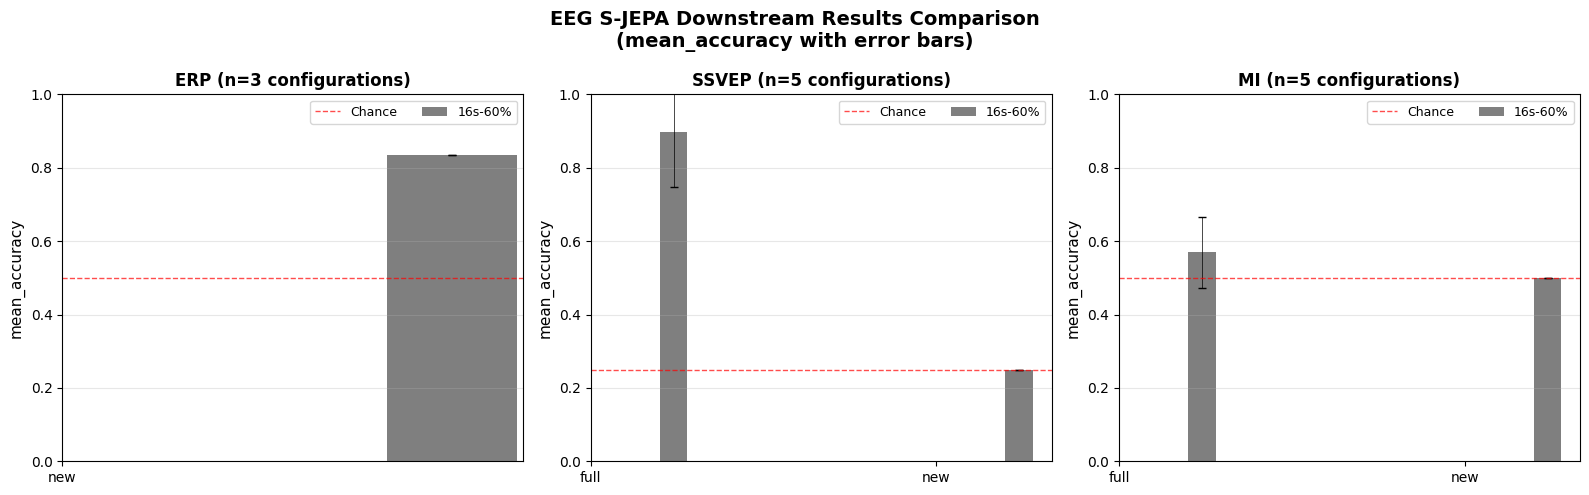

In [16]:
# Generate comparison plot
colors = get_pretraining_colors(CONFIG["pretraining_order"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"EEG S-JEPA Downstream Results Comparison\n({CONFIG['metric_key']} with error bars)",
             fontsize=14, fontweight="bold")

for idx, paradigm in enumerate(CONFIG["paradigm_order"]):
    plot_paradigm_comparison(
        paradigm=paradigm,
        successful_results=successful_results,
        CONFIG=CONFIG,
        colors=colors,
        ax=axes[idx],
    )

plt.tight_layout()
print("\nComparison plot created.")
plt.show()

# 6. Save Outputs

## 6.1. Save Figure

In [17]:
if CONFIG["save_figures"]:
    png_path = ARTIFACT_DIR / "comparison_plot.png"
    pdf_path = ARTIFACT_DIR / "comparison_plot.pdf"
    
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    
    print("Figure saved:")
    print(f"  - PNG: {png_path}")
    print(f"  - PDF: {pdf_path}")
else:
    print("Figure saving disabled in CONFIG.")

[2026-04-16 10:56:17] Figure saved:
[2026-04-16 10:56:17]   - PNG: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1056_project_comparison_b11605e6/comparison_plot.png
[2026-04-16 10:56:17]   - PDF: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1056_project_comparison_b11605e6/comparison_plot.pdf


## 6.2. Save Results Table

In [18]:
if CONFIG["save_tables"]:
    # Successful results
    csv_path = ARTIFACT_DIR / "results_table.csv"
    json_path = ARTIFACT_DIR / "results_table.json"
    
    successful_results.to_csv(csv_path, index=False)
    successful_results.to_json(json_path, orient="records", indent=2)
    
    print("Results table saved:")
    print(f"  - CSV:  {csv_path}")
    print(f"  - JSON: {json_path}")
    
    # Missing results
    if len(missing_results) > 0:
        missing_csv_path = ARTIFACT_DIR / "missing_results.csv"
        missing_results.to_csv(missing_csv_path, index=False)
        print(f"  - Missing CSV: {missing_csv_path}")
else:
    print("Table saving disabled in CONFIG.")

[2026-04-16 10:56:17] Table saving disabled in CONFIG.


## 6.3. Save Summary

In [19]:
summary = {
    "run_id": RUN_ID,
    "timestamp": datetime.now().isoformat(),
    "total_configured_combinations": len(all_results),
    "total_successfully_loaded": len(successful_results),
    "total_missing_or_invalid": len(missing_results),
    "metric_key": CONFIG["metric_key"],
    "paradigm_coverage": {
        paradigm: {
            "loaded": len(successful_results[successful_results["paradigm"] == paradigm]),
            "total": len(all_results[all_results["paradigm"] == paradigm]),
        }
        for paradigm in CONFIG["paradigm_order"]
    },
    "output_files": {
        "config": "config.json",
        "results_csv": "results_table.csv",
        "results_json": "results_table.json",
        "missing_csv": "missing_results.csv",
        "plot_png": "comparison_plot.png",
        "plot_pdf": "comparison_plot.pdf",
        "log": "run.log",
    },
}

summary_path = ARTIFACT_DIR / "summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Summary saved to: {summary_path}")

[2026-04-16 10:56:17] Summary saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1056_project_comparison_b11605e6/summary.json


# 7. Final Summary

In [20]:
print("\n" + "=" * 70)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 70)

print(f"\nRun ID: {RUN_ID}")
print(f"Artifact Directory: {ARTIFACT_DIR}")

print("\nResults Summary:")
print(f"  Total configured combinations: {len(all_results)}")
print(f"  Successfully loaded:           {len(successful_results)}")
print(f"  Missing / invalid:             {len(missing_results)}")

print("\nCoverage by Paradigm:")
for paradigm in CONFIG["paradigm_order"]:
    paradigm_ok = successful_results[successful_results["paradigm"] == paradigm]
    paradigm_all = all_results[all_results["paradigm"] == paradigm]
    pct = 100 * len(paradigm_ok) / len(paradigm_all) if len(paradigm_all) > 0 else 0
    print(f"  {paradigm:8s}: {len(paradigm_ok):3d} / {len(paradigm_all):3d} ({pct:5.1f}%)")

print("\nGenerated Outputs:")
artifacts = list(ARTIFACT_DIR.iterdir())
for artifact in sorted(artifacts):
    size_mb = artifact.stat().st_size / (1024 * 1024)
    print(f"  - {artifact.name:30s} ({size_mb:.2f} MB)")

print("\n" + "=" * 70)

if len(successful_results) > 0:
    print("\n✓ Results successfully loaded and visualized.")
    print(f"  Next: Review the outputs in {ARTIFACT_DIR}")
else:
    print("\n⚠ No results loaded yet.")
    print("  Next: Update RESULT_PATHS with actual artifact folder paths.")

print("\n" + "=" * 70)


[2026-04-16 10:56:17] ======================================================================
[2026-04-16 10:56:17] NOTEBOOK EXECUTION COMPLETE
[2026-04-16 10:56:17] ======================================================================

[2026-04-16 10:56:17] Run ID: 20260416_1056_project_comparison_b11605e6
[2026-04-16 10:56:17] Artifact Directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/downstream_comparisons/20260416_1056_project_comparison_b11605e6

[2026-04-16 10:56:17] Results Summary:
[2026-04-16 10:56:17]   Total configured combinations: 162
[2026-04-16 10:56:17]   Successfully loaded:           13
[2026-04-16 10:56:17]   Missing / invalid:             149

[2026-04-16 10:56:17] Coverage by Paradigm:
[2026-04-16 10:56:17]   ERP     :   3 /  54 (  5.6%)
[2026-04-16 10:56:17]   SSVEP   :   5 /  54 (  9.3%)
[2026-04-16 10:56:17]   MI      :   5 /  54 (  9.3%)

[2026-04-16 10:56:17] Generated Outputs:
[2026-04-16 10:56:17]   - comparison_plo